# 03 — Greeks Analysis

Visualise how the five Black-Scholes Greeks — Δ, Γ, Θ, ν (vega), ρ — vary
across strikes, maturities, and spot levels.


In [3]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from pricer.models import OptionParams
from pricer.black_scholes import greeks, price as bs_price


## 1. All Greeks vs Strike (fixed T=1, S=100, σ=0.2)

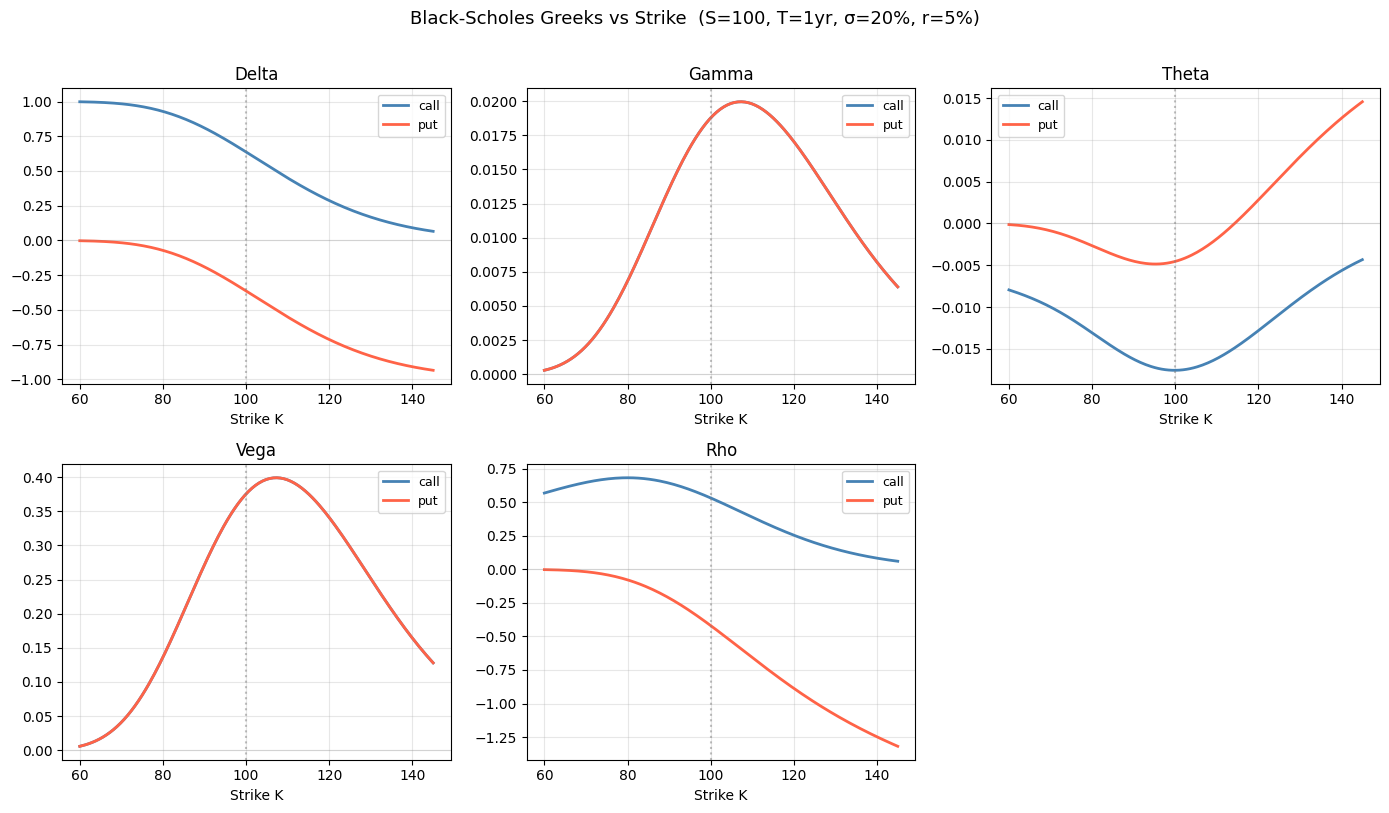

In [4]:
strikes = np.linspace(60, 145, 200)
greek_names = ['delta', 'gamma', 'theta', 'vega', 'rho']
greek_data = {g: {'call': [], 'put': []} for g in greek_names}

for K in strikes:
    p = OptionParams(S=100, K=K, T=1.0, r=0.05, sigma=0.2)
    for kind in ('call', 'put'):
        g = greeks(p, kind)
        for name in greek_names:
            greek_data[name][kind].append(g[name])

colors = {'call': 'steelblue', 'put': 'tomato'}
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, name in enumerate(greek_names):
    ax = axes[i]
    for kind in ('call', 'put'):
        ax.plot(strikes, greek_data[name][kind],
                label=kind, color=colors[kind], lw=2)
    ax.axvline(100, color='grey', ls=':', alpha=0.5)
    ax.axhline(0,   color='grey', ls='-', alpha=0.2, lw=0.8)
    ax.set_xlabel('Strike K')
    ax.set_title(name.capitalize())
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Black-Scholes Greeks vs Strike  (S=100, T=1yr, σ=20%, r=5%)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/greeks_vs_strike.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Delta and Gamma vs Spot (holding K fixed)

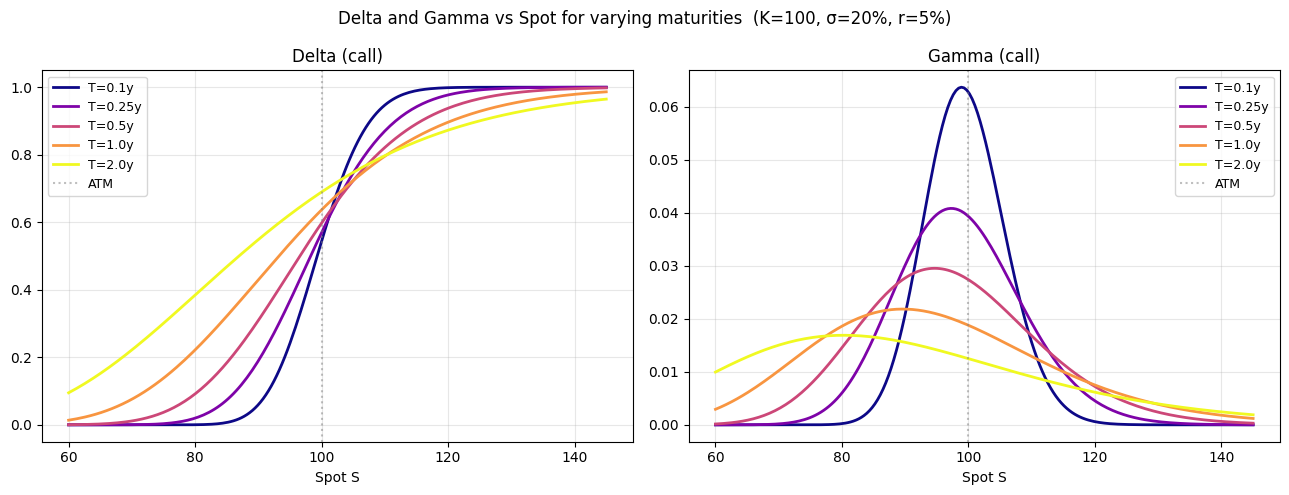

In [5]:
spots = np.linspace(60, 145, 200)
K_fixed = 100
Ts = [0.1, 0.25, 0.5, 1.0, 2.0]
cmap = cm.get_cmap('plasma', len(Ts))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, T in enumerate(Ts):
    deltas = [greeks(OptionParams(S=s, K=K_fixed, T=T, r=0.05, sigma=0.2), 'call')['delta']
              for s in spots]
    gammas = [greeks(OptionParams(S=s, K=K_fixed, T=T, r=0.05, sigma=0.2), 'call')['gamma']
              for s in spots]
    label = f'T={T}y'
    axes[0].plot(spots, deltas, color=cmap(i), lw=2, label=label)
    axes[1].plot(spots, gammas, color=cmap(i), lw=2, label=label)

for ax, name in zip(axes, ['Delta (call)', 'Gamma (call)']):
    ax.axvline(K_fixed, color='grey', ls=':', alpha=0.5, label='ATM')
    ax.set_xlabel('Spot S')
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Delta and Gamma vs Spot for varying maturities  (K=100, σ=20%, r=5%)',
             fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/delta_gamma_vs_spot.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Theta decay — price vs time to expiry

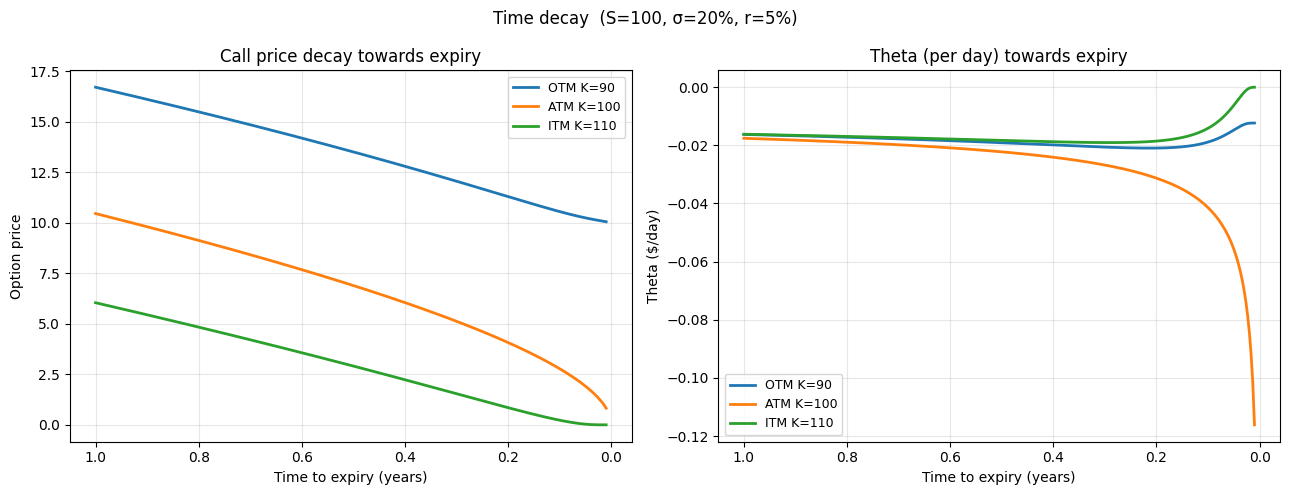

In [6]:
times = np.linspace(0.01, 1.0, 300)[::-1]   # T → 0 (decay)
moneyness_cases = [(90, 'OTM K=90'), (100, 'ATM K=100'), (110, 'ITM K=110')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for K, label in moneyness_cases:
    prices = [bs_price(OptionParams(S=100, K=K, T=t, r=0.05, sigma=0.2), 'call')
              for t in times]
    thetas = [greeks(OptionParams(S=100, K=K, T=t, r=0.05, sigma=0.2), 'call')['theta']
              for t in times]
    axes[0].plot(times, prices, lw=2, label=label)
    axes[1].plot(times, thetas, lw=2, label=label)

for ax in axes:
    ax.invert_xaxis()
    ax.set_xlabel('Time to expiry (years)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_title('Call price decay towards expiry')
axes[0].set_ylabel('Option price')
axes[1].set_title('Theta (per day) towards expiry')
axes[1].set_ylabel('Theta ($/day)')

plt.suptitle('Time decay  (S=100, σ=20%, r=5%)', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/theta_decay.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Vega — sensitivity to volatility

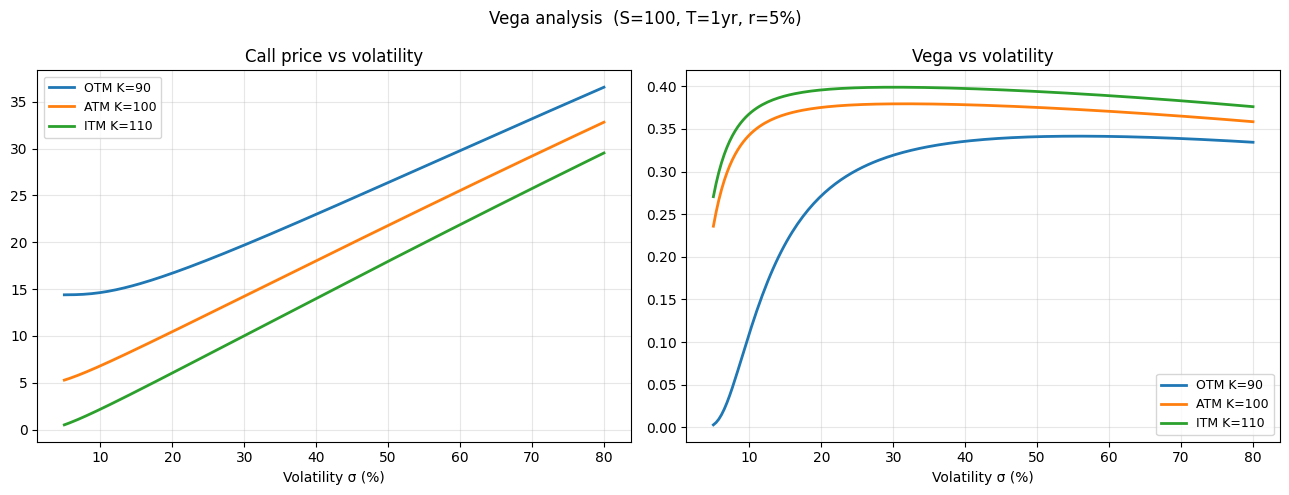

In [7]:
sigmas = np.linspace(0.05, 0.80, 200)
K_cases = [(90, 'OTM K=90'), (100, 'ATM K=100'), (110, 'ITM K=110')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for K, label in K_cases:
    prices = [bs_price(OptionParams(S=100, K=K, T=1.0, r=0.05, sigma=s), 'call')
              for s in sigmas]
    vegas  = [greeks(OptionParams(S=100, K=K, T=1.0, r=0.05, sigma=s), 'call')['vega']
              for s in sigmas]
    axes[0].plot(sigmas * 100, prices, lw=2, label=label)
    axes[1].plot(sigmas * 100, vegas,  lw=2, label=label)

for ax, title in zip(axes, ['Call price vs volatility', 'Vega vs volatility']):
    ax.set_xlabel('Volatility σ (%)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Vega analysis  (S=100, T=1yr, r=5%)', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks/vega_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Greeks heatmap — Delta across (S, σ)

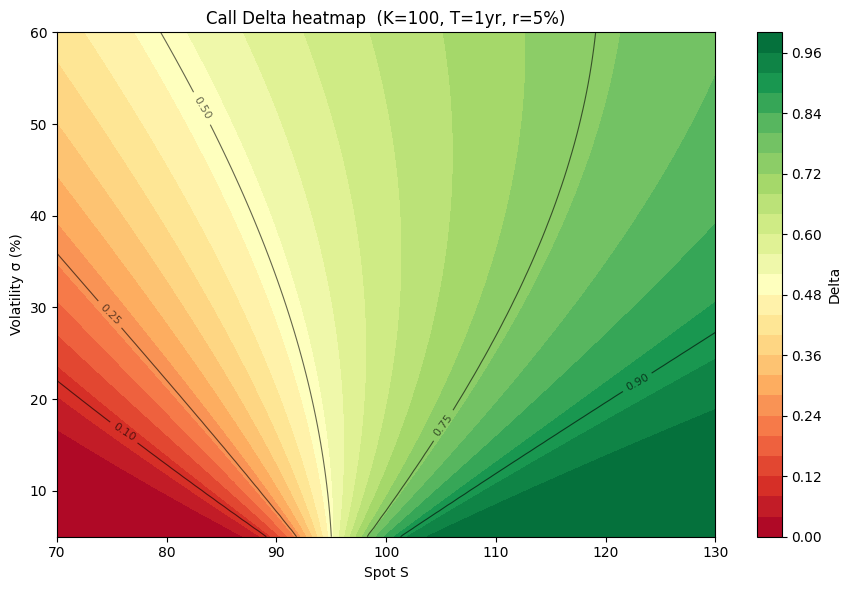

In [8]:
S_range     = np.linspace(70, 130, 60)
sigma_range = np.linspace(0.05, 0.60, 60)
SS, SigSig = np.meshgrid(S_range, sigma_range)

delta_grid = np.array([
    [greeks(OptionParams(S=s, K=100, T=1.0, r=0.05, sigma=sig), 'call')['delta']
     for s in S_range]
    for sig in sigma_range
])

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.contourf(SS, SigSig * 100, delta_grid, levels=30, cmap='RdYlGn')
cs = ax.contour(SS, SigSig * 100, delta_grid, levels=[0.1,0.25,0.5,0.75,0.9],
                colors='k', linewidths=0.8, alpha=0.6)
ax.clabel(cs, fmt='%.2f', fontsize=8)
fig.colorbar(im, ax=ax, label='Delta')
ax.set_xlabel('Spot S')
ax.set_ylabel('Volatility σ (%)')
ax.set_title('Call Delta heatmap  (K=100, T=1yr, r=5%)')
plt.tight_layout()
plt.savefig('../notebooks/delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
